# Equivalent eigenstrain

A fully contained NumPy teaching solver. Run cells from top to bottom in Jupyter or Google Colab. Requires NumPy and Matplotlib. New teaching code: GPL-3.0-or-later.

Change the parameter cell and rerun the cells below it to explore.

## Derive before iterating

The physical eigenstrain $\epsilon^0$ describes the strain the precipitate would adopt without constraint. The total strain must come from a displacement:
$$\epsilon=E+\tfrac12(\nabla u+\nabla u^T),\qquad \sigma=C(x):(\epsilon-\epsilon^0),\qquad \partial_j\sigma_{ij}=0.$$
We prescribe the mean **total** strain $E$ in a periodic unit square. Default $E=0$ is clamping, not zero mean stress. The energy is
$$F/V=\tfrac12\langle(\epsilon-\epsilon^0):C(x):(\epsilon-\epsilon^0)\rangle.$$
Both tensor shear entries are stored. $\sigma_{xy}=2C_{44}\epsilon^{el}_{xy}$. This is small-strain 2-D cubic-block elasticity, with $\epsilon_{zz}=\epsilon^0_{zz}=0$, not plane stress. Material constants and coordinates are dimensionless.

Imagine a uniform reference solid carrying an auxiliary eigenstrain $\eta$. Require its stress to equal the physical stress:
$$C^{ref}:(\epsilon-\eta)=C(x):(\epsilon-\epsilon^0).$$
Applying $S^{ref}=(C^{ref})^{-1}$ on symmetric tensors gives
$$\eta_{target}=\epsilon-S^{ref}:C:(\epsilon-\epsilon^0).$$
1. Start with $\eta=\epsilon^0$.
2. Solve the uniform-reference equilibrium problem with $\eta$.
3. Compute the true stress and compare it with the reference stress.
4. Correct $\eta$ with $-\omega S^{ref}:(\sigma-\sigma^{ref})$.
5. Check both physical equilibrium and stress matching.

$\eta$ is a computational field, not the physical transformation strain. Energy must use the real $C(x)$ and $\epsilon^0$. This constitutive-matching update illustrates the equivalent-eigenstrain idea used in Soumya's work; it is not his film/vacuum relaxation law.


## Fourier and tensor routines
Read `stress`, `PeriodicGrid.response`, and the iteration below first. FFTs act only on the two spatial axes. Odd grids avoid Nyquist derivative ambiguity. The shared routines are embedded here so this notebook needs no companion files.

In [1]:
"""Transparent 2-D periodic elasticity helpers. GPL-3.0-or-later.
Arrays have shape (Nx, Ny, 2, 2). Both shear entries are stored:
epsilon_xy is tensor shear, so sigma_xy = 2*C44*epsilon_xy.
Use odd grids: they avoid even-grid Nyquist derivative ambiguities.
"""
import numpy as np


def cubic(c11=4.0, c12=2.0, c44=1.0):
    """In-plane cubic stiffness, with epsilon_zz^0 = epsilon_zz = 0.
    This is not a plane-stress reduction. Constants are dimensionless.
    """
    if not np.all(np.isfinite([c11, c12, c44])) or min(c44, c11-c12, c11+2*c12) <= 0:
        raise ValueError('Use stable cubic constants: C44>0, C11-C12>0, C11+2*C12>0.')
    stiffness = np.zeros((2, 2, 2, 2))
    for i in range(2):
        for j in range(2):
            for k in range(2):
                for l in range(2):
                    if i == j == k == l:
                        stiffness[i,j,k,l] = c11
                    elif i == j and k == l:
                        stiffness[i,j,k,l] = c12
                    elif (i == k and j == l) or (i == l and j == k):
                        stiffness[i,j,k,l] = c44
    return stiffness


def stress(stiffness, strain):
    """sigma_ij = sum_kl C_ijkl epsilon_kl; spatial axes are preserved."""
    return np.einsum('...ijkl,...kl->...ij', stiffness, strain)


def reference_compliance(reference, tensor):
    """Inverse on symmetric tensors, explicitly retaining tensor shear."""
    c11, c12, c44 = reference[0,0,0,0], reference[0,0,1,1], reference[0,1,0,1]
    result = np.empty_like(tensor)
    result[...,0,0] = (c11*tensor[...,0,0]-c12*tensor[...,1,1])/(c11*c11-c12*c12)
    result[...,1,1] = (c11*tensor[...,1,1]-c12*tensor[...,0,0])/(c11*c11-c12*c12)
    result[...,0,1] = tensor[...,0,1]/(2*c44)
    result[...,1,0] = result[...,0,1]
    return result


class PeriodicGrid:
    """Fourier differentiation on a unit square, x along array axis 0."""
    def __init__(self, size=65):
        if size < 5 or size % 2 != 1:
            raise ValueError('Choose an odd grid size of at least 5, e.g. 33, 65, 129.')
        self.size = size
        wave = 2*np.pi*np.fft.fftfreq(size, d=1/size)
        self.wave = np.stack(np.meshgrid(wave, wave, indexing='ij'), axis=-1)

    def transform(self, field):
        return np.fft.fftn(field, axes=(0,1))

    def inverse(self, field):
        return np.fft.ifftn(field, axes=(0,1)).real

    def strain(self, displacement):
        gradient_hat = 1j*np.einsum('...i,...j->...ij', self.transform(displacement), self.wave)
        return self.inverse((gradient_hat+gradient_hat.swapaxes(-1,-2))/2)

    def divergence(self, tensor):
        return self.inverse(1j*np.einsum('...ij,...j->...i', self.transform(tensor), self.wave))

    def response(self, reference, polarization):
        """Solve div(Cref:sym grad u - P)=0, mean(u)=0.
        Q_ik(k)=Cref_ijkl k_j k_l. u_hat=-i Q(k)^-1 P_hat.k.
        Full wavevectors are used: no missing |k|^-2 factor.
        """
        acoustic = np.einsum('ijkl,...j,...l->...ik', reference, self.wave, self.wave)
        acoustic[0,0] = np.eye(2)  # temporary only; displacement zero mode set below
        force_hat = np.einsum('...ij,...j->...i', self.transform(polarization), self.wave)
        displacement_hat = -1j*np.linalg.solve(acoustic, force_hat[...,None])[...,0]
        displacement_hat[0,0] = 0
        return self.inverse(displacement_hat)


def rms(array):
    return float(np.sqrt(np.mean(np.abs(array)**2)))


def prepare(stiffness, eigenstrain, mean_strain, reference, relaxation, tolerance, max_iterations):
    n = eigenstrain.shape[0]
    grid = PeriodicGrid(n)
    if eigenstrain.shape != (n,n,2,2) or stiffness.shape != (n,n,2,2,2,2):
        raise ValueError('Expected square fields of symmetric 2-D tensors.')
    if not 0 < relaxation <= 1 or tolerance <= 0 or max_iterations < 1:
        raise ValueError('Use 0 < relaxation <= 1, positive tolerance and iteration limit.')
    mean_strain = np.zeros((2,2)) if mean_strain is None else np.asarray(mean_strain,dtype=float)
    if mean_strain.shape != (2,2) or not np.allclose(mean_strain, mean_strain.T):
        raise ValueError('Mean strain must be a symmetric 2 by 2 tensor.')
    if not all(np.all(np.isfinite(a)) for a in [stiffness,eigenstrain,mean_strain,reference]):
        raise ValueError('All inputs must be finite.')
    # Normalize equilibrium by the initial forcing, retaining a finite scale
    # for uniform loading (whose initial divergence may be exactly zero).
    initial_stress = stress(stiffness, mean_strain-eigenstrain)
    scale = max(rms(grid.divergence(initial_stress)), 2*np.pi*rms(initial_stress), 1e-30)
    return grid, mean_strain, scale


def diagnostics(grid, stiffness, eigenstrain, strain, scale):
    elastic_strain = strain-eigenstrain
    sigma = stress(stiffness, elastic_strain)
    energy_density = 0.5*np.sum(elastic_strain*sigma, axis=(-2,-1))
    residual = rms(grid.divergence(sigma))/scale
    return sigma, energy_density, residual


def result(grid, stiffness, eigenstrain, strain, displacement, scale, history, **extra):
    sigma, energy_density, residual = diagnostics(grid,stiffness,eigenstrain,strain,scale)
    return dict(strain=strain, displacement=displacement, stress=sigma,
                energy_density=energy_density, energy=float(energy_density.mean()),
                residual=residual, history=np.asarray(history), **extra)


def plate_problem(size=65, contrast=0.5, angle=30.0, misfit_ratio=-0.5,
                  matrix_constants=(4.,2.,1.), precipitate_constants=None):
    """A smooth periodic plate. angle is its long-axis angle from x, in degrees.
    Rotate the shape, keeping stiffness and physical eigenstrain crystal-fixed.
    Optional independent precipitate_constants override scalar contrast.
    """
    PeriodicGrid(size)
    matrix = cubic(*matrix_constants)
    precipitate = cubic(*(np.asarray(matrix_constants)*contrast if precipitate_constants is None else precipitate_constants))
    x,y = np.meshgrid(np.arange(size)/size-.5,np.arange(size)/size-.5,indexing='ij')
    theta = np.deg2rad(angle)
    along = x*np.cos(theta)+y*np.sin(theta)
    across = -x*np.sin(theta)+y*np.cos(theta)
    radius_squared = (along/.23)**2+(across/.075)**2
    # Smooth fixed interface width in physical coordinates, not in pixels.
    phase = .5*(1-np.tanh((radius_squared-1)/.35))
    stiffness = matrix+phase[...,None,None,None,None]*(precipitate-matrix)
    eigenstrain = phase[...,None,None]*np.diag([.01,.01*misfit_ratio])
    reference = .5*(matrix+precipitate)
    return stiffness,eigenstrain,reference,phase


def plot_solution(solution, phase):
    """Plot geometry, physical fields and residual, with readable rainbow maps."""
    import matplotlib.pyplot as plt
    figure, axes = plt.subplots(1,4,figsize=(15,3.5),layout='constrained')
    for axis,field,title in zip(axes[:3], [phase,solution['stress'][...,0,0],solution['energy_density']],
                               ['Precipitate fraction h',r'$\sigma_{xx}$','Elastic energy density']):
        image=axis.imshow(field.T,origin='lower',extent=[0,1,0,1],cmap='rainbow')
        axis.set(title=title,xlabel='x',ylabel='y')
        figure.colorbar(image,ax=axis,shrink=.8)
    history=solution['history']
    axes[3].semilogy(history[:,0],np.maximum(history[:,1],1e-16))
    axes[3].set(xlabel='Iteration',ylabel='Equilibrium residual',title='Convergence')
    return figure


## The complete iteration
Relaxation is a numerical mixing parameter, not physical time. Failed convergence raises an error. The reported residual checks the physical stress divergence.

In [2]:
def solve_equivalent(stiffness,eigenstrain,reference,mean_strain=None,
                     relaxation=0.8,tolerance=1e-8,max_iterations=4000):
    grid,mean_strain,scale=prepare(stiffness,eigenstrain,mean_strain,reference,
                                  relaxation,tolerance,max_iterations)
    # eta is an auxiliary eigenstrain, NOT the physical transformation strain.
    eta=eigenstrain.copy()
    history=[]
    stress_scale=max(rms(stress(stiffness,mean_strain-eigenstrain)),1e-30)
    for iterator in range(max_iterations+1):
        # Every step equilibrates a homogeneous reference solid with eigenstrain eta.
        displacement=grid.response(reference,stress(reference,eta))
        strain=mean_strain+grid.strain(displacement)
        sigma,energy_density,residual=diagnostics(grid,stiffness,eigenstrain,strain,scale)
        reference_stress=stress(reference,strain-eta)
        mismatch=sigma-reference_stress
        mismatch_norm=rms(mismatch)/stress_scale
        history.append([iterator,residual,float(energy_density.mean()),mismatch_norm])
        if max(residual,mismatch_norm)<tolerance:
            return result(grid,stiffness,eigenstrain,strain,displacement,scale,history,
                          equivalent_eigenstrain=eta,constitutive_mismatch=mismatch_norm)
        # Cref:(epsilon-eta) = C:(epsilon-epsilon0).
        # Thus eta_new = epsilon - Sref:C:(epsilon-epsilon0).
        # Equivalently eta_new = eta - Sref:(sigma-sigma_reference).
        eta -= relaxation*reference_compliance(reference,mismatch)
        if not np.isfinite(residual+mismatch_norm) or max(residual,mismatch_norm)>1e12:
            break
    raise RuntimeError(f'Equivalent-eigenstrain iteration did not converge; '
                       f'equilibrium={residual:.3e}, matching={mismatch_norm:.3e}.')




## Choose the experiment
Rotate the plate shape while holding crystal axes and eigenstrain fixed. Use 33 for quick exploration, then 65 and 129 for convergence. Independent precipitate constants override the scalar modulus ratio.

In [3]:
size = 65
modulus_ratio = 0.5
plate_angle = 30.0      # degrees from x to the long axis
misfit_ratio = -0.5    # epsilon_yy^0 / epsilon_xx^0
matrix_constants = (4.0, 2.0, 1.0)  # C11, C12, C44
precipitate_constants = None        # try (6.0, 1.0, 0.7)
mean_strain = np.zeros((2, 2))       # total strain, not elastic strain
relaxation = 0.8

stiffness, eigenstrain, reference, phase = plate_problem(
    size, modulus_ratio, plate_angle, misfit_ratio,
    matrix_constants, precipitate_constants)


Energy per area: 2.227523024719576e-06
Equilibrium residual: 6.043532062822316e-09
Mean total strain:
 [[-6.82854907e-20  1.89895765e-21]
 [ 1.89895765e-21  1.55252619e-21]]


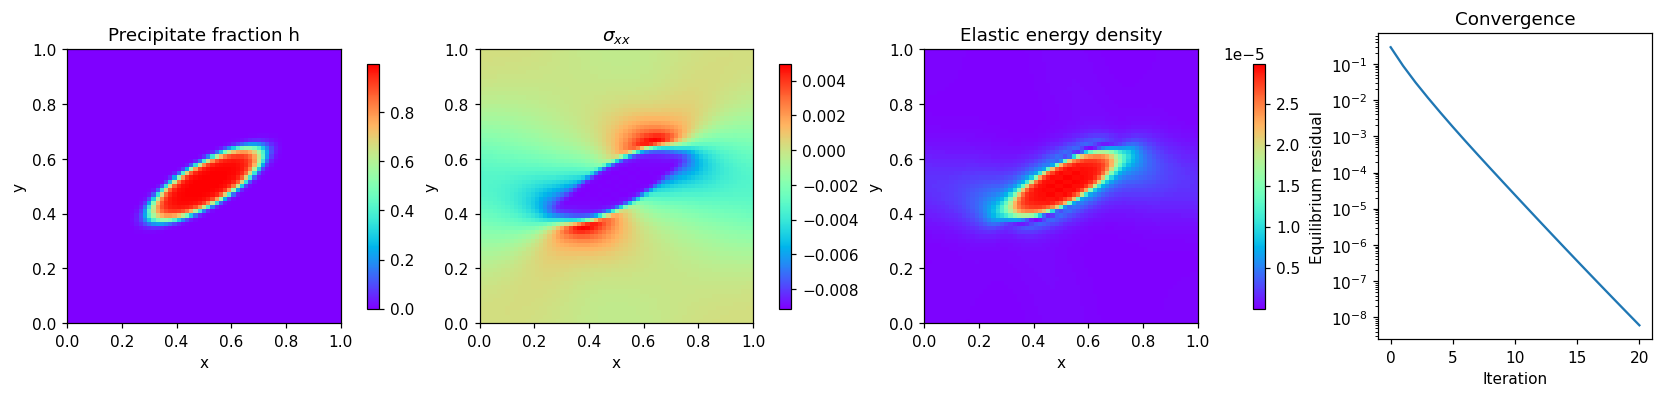

In [4]:
solution = solve_equivalent(stiffness, eigenstrain, reference,
    mean_strain=mean_strain, relaxation=relaxation)
print("Energy per area:", solution['energy'])
print("Equilibrium residual:", solution['residual'])
print("Mean total strain:\n", solution['strain'].mean(axis=(0, 1)))
figure = plot_solution(solution, phase)
import matplotlib.pyplot as plt
plt.show()


## What did the auxiliary field replace?
Compare the transformation strain with the equivalent eigenstrain and their difference. A nonzero auxiliary field outside the precipitate can be required by the reference-medium representation; it is not a physical transformation of the matrix.

Relative stress mismatch: 1.5021484936703525e-09


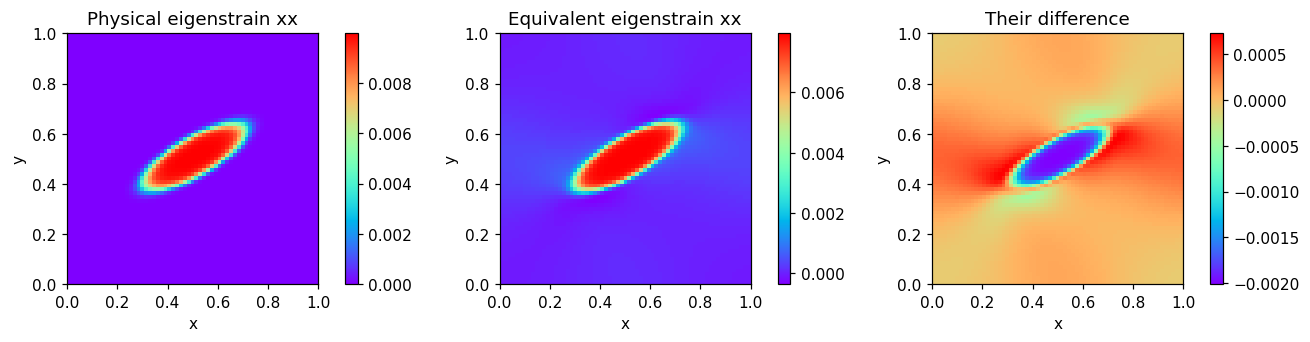

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), layout='constrained')
eta = solution['equivalent_eigenstrain']
for axis, field, label in zip(axes,
    [eigenstrain[...,0,0], eta[...,0,0], eta[...,0,0]-eigenstrain[...,0,0]],
    ['Physical eigenstrain xx', 'Equivalent eigenstrain xx', 'Their difference']):
    image = axis.imshow(field.T, origin='lower', cmap='rainbow', extent=[0,1,0,1])
    axis.set(title=label, xlabel='x', ylabel='y')
    fig.colorbar(image, ax=axis)
print('Relative stress mismatch:', solution['constitutive_mismatch'])
plt.show()


## Rotate a prescribed plate
This is a sampled orientation scan, not a simulation of shape evolution. Refinement of both angle and spatial grid is needed when minima are close. The finite plate has fixed aspect ratio and a diffuse interface.

Lowest sampled angle: 110.0


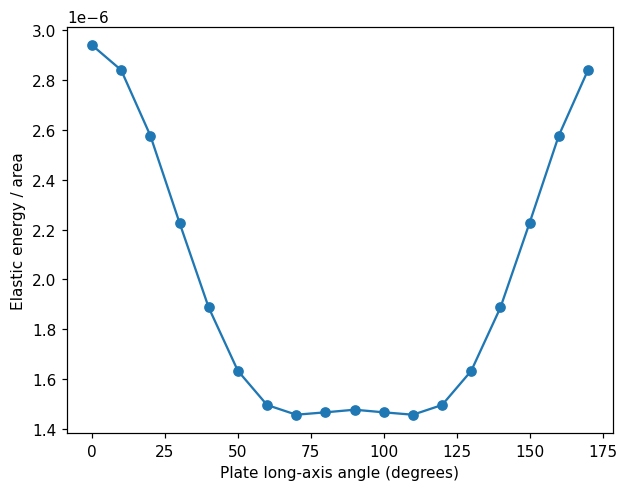

In [6]:
angles = np.arange(0.0, 180.0, 10.0)
energies = []
for angle in angles:
    stiffness, eigenstrain, reference, phase = plate_problem(
        size, modulus_ratio, angle, misfit_ratio,
        matrix_constants, precipitate_constants)
    trial = solve_equivalent(stiffness, eigenstrain, reference,
        mean_strain=mean_strain, relaxation=relaxation)
    energies.append(trial['energy'])
fig, axis = plt.subplots()
axis.plot(angles, energies, 'o-')
axis.set(xlabel='Plate long-axis angle (degrees)', ylabel='Elastic energy / area')
plt.show()
print('Lowest sampled angle:', angles[np.argmin(energies)])


## Read the result physically

The favored sampled orientation makes the prescribed transformation strain least costly under this stiffness field, shape and macroscopic constraint. It need not be a zero-energy habit line. The physical elastic strain is total strain minus transformation strain. A residual trace that stalls is a numerical warning, not a new physical steady state.

Try modulus ratio 1, then 0.2 and 5. Change the eigenstrain ratio separately from elastic anisotropy. Repeat at 33, 65 and 129 points with unchanged geometry. Compare the two solvers on the same inputs. They are related fixed-point formulations, so also run the independent tests in the downloadable source bundle.

## Provenance and limits

Direct reference: Bhattacharyya, Heo, Chang and Chen, CICP 11 (2012), 726–738, [spectral iterative method](https://doi.org/10.4208/cicp.290610.060411a), together with the group's earlier C/Fortran implementations. Related notation: Tushar Jogi's thesis §§3.1.4–3.1.6 and Appendix B.

Equivalent eigenstrain: inspired by Soumya Bandyopadhyay's group code; this two-solid constitutive-matching iteration is independently derived, not a reproduction of the original ferroelectric film/vacuum algorithm. No zero-stiffness phase, traction-free outer surface, evolving phase field or 3-D inclusion is modeled here.

See the [full derivation, convergence definition and source notes](https://saswataiith.github.io/files/elastic-solvers/README.md) and [numerical checks](https://saswataiith.github.io/files/elastic-solvers/validation.json).
